#### Name: Ben Maxwell

# PHYS 230 Lab Assignment 16

### Monday, April 6, 2026: Chapter 8.6
- Boundary Value Problems

*Don't forget to put a markdown cell at the end of each problem explaining your process and results AND comments in all cells*

In [1]:
# import statements here
import numpy as np
import matplotlib.pyplot as plt

### The Shooting Method

Find a solution to the boundary value problem: 
$$\frac{d^2y}{dt^2} = -y$$
where $y$ is the position of an object, and $y(t=0) = 1$ and $y(t=1) = 2$. To do this, complete the following steps: 

#### Step 1: In a markdown, write the two simultaneous single-order differential equations that you will use to solve this second-order differential equation. (Convert the cell below to markdown first)

$$\frac{dv}{dt} = -y $$

$$ \frac{dy}{dt} = v$$

#### Step 2: Write a function `f(r,t)` that will calculate the two equations written in step 1 using a vector `r` that containts two elements. 

In [23]:
#Defing the function 
def f(r,t):
    y = r[0] 
    v = r[1]

    fv = -y
    fy = v

    return np.array([fy,fv],float)

In thus cell, I create a function f(r,t) which takes an array r and a time t, and calculates the values of the differential equations above. In this scenario, fv = -y, and fy = v. Then an array of the answers are returned. 

#### Step 3: Define any constants, boundary conditions, and arrays necessary for the problem and solve for the initial velocity $\left(\frac{dy}{dt}\right)$. 

In [ ]:


#Define range of values
t1 = 0. #s
t2 = 1. #s
nsteps = 1000
h = (t2-t1)/nsteps
tpts = np.arange(t1, t2+h,h)

#### Step 4: Use fourth-order Runge-Kutta combined with the binary search method to find the initial velocity ($\frac{dy}{dt}$) that solves the boundary value problem. Note: in this case the final point is not 0. In order to use binary search, you will need to subtract the final height from the runge-kutta found height using your initial guess to see if it is zero or not. 

In [ ]:
#Apply 4th order runge-kutta to calculate height. 
def RK4(v,tpts,h):
    #tpts is an array of time values spaced by h
    #v = initial velocity guess
    r = np.array([1,v], float)
    for t in tpts:
        k1 = h*f(r,t)
        k2 = h*f(r+0.5*k1, t+0.5*h)
        k3 = h*f(r+0.5*k2, t+0.5*h)
        k4 = h*f(r+k3, t+h)
        r += (k1 + 2*k2 + 2*k3 + k4)/6
    return r[0]

#Apply binary search
#Choose target accuracy
target = 1e-10
#Set inital values
v1 = 0.01
v2 = 999
h1 = RK4(v1,tpts,h)-2
h2 = RK4(v2,tpts, h)-2

#Applying binary search
while abs(h2-h1)>target:
    vp = (v1+v2)/2
    hp = RK4(vp,tpts,h)-2
    if h1*hp > 0:
        v1 = vp
        h1 = hp
    else: 
        v2 = vp
        h2 = hp

v = (v1+v2)/2
print(v)

-1.4521193264646648 839.7083159868367
1.7345850196985602


To start I began my code by defining a function that gives back the runge kutta of the v, tpts, and h. Then, I defined the target, along with initial values of v1, v2, and calculate the initial heights h1 and h2. Then, I used binary search to go through the values until the initial v was found. Mostly I just followed these methods. Some big things to note are that my initial guess for velocity is 2, andthat I always subtracted 2 from the height since the height is offset by 2. 

#### Step 5: Analyze the accuracy of your result. One way you could do this is to plug your two now initial conditions back into fourth-order runge-kutta to solve for all $y$ values and make a plot of $y$ vs. $t$. In a markdown cell, briefly comment on the results. 

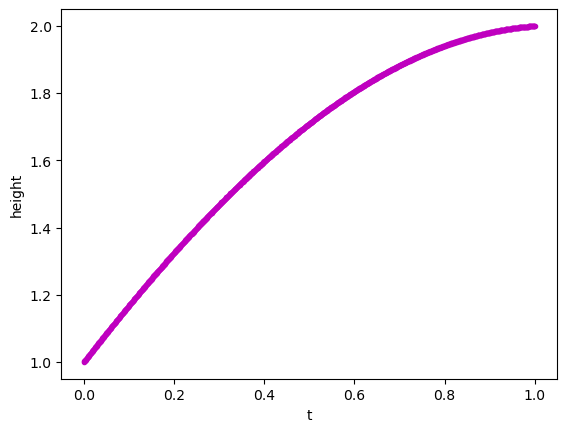

1.9999999999594626


In [ ]:

tpts = np.arange(t1,t2+h,h)
ypts = np.zeros(len(tpts))
vpts = np.zeros(len(tpts))

#Initial values
r = np.array([1,v], float)
#Apply 4th order runge-kutta to calculate height. 
#tpts is an array of time values spaced by h
for i in range(len(tpts)):
    ypts[i] = r[0]
    vpts[i] = r[1]
    k1 = h*f(r,tpts[i])
    k2 = h*f(r+0.5*k1, tpts[i]+0.5*h)
    k3 = h*f(r+0.5*k2, tpts[i]+0.5*h)
    k4 = h*f(r+k3, tpts[i]+h)
    r += (k1 + 2*k2 + 2*k3 + k4)/6

#Set the final
ypts[-1] = r[0]
vpts[-1] = r[1]

plt.plot(tpts,ypts,".m")
plt.xlabel("t")
plt.ylabel("height")
plt.show()

print(ypts[-1])

For this, I plugged in my two initial values back my array, and then I plotted my function using Runge Kutta. The graph I got makes sense, as 1 is my initial height and 2 is my final height. 

### Eigenvalue Problems 

Find the smallest positive eigenvalue $z$ for the equation:
	    $$\frac{d^2y}{dt^2} = -z y$$
	    where $y(t =-1) = 0$ and $y(t = 1) = 0$. Try searching in the range $0.0 \leq z \leq 10.0$. To do this, complete the following steps:

#### Step 1: define the function `f(r,t,z)` that applies values (including your initial guess of $z$ and a vector `r` that containts two elements) to the two first-order differential equations needed for this problem. You may find it beneficial to write our your two first-order differential equations first. 

$$\frac{dy}{dt} = v $$
$$\frac{dv}{dt} =  -zy $$

In [30]:
def f(r,t,z):
    y = r[0] 
    v = r[1]

    fv = -z*y
    fy = v

    return np.array([fy,fv],float) 

In this code I just define a function that returns the two differential equations I found above in the form of an array. It does this based off of an array r, and a given value z.

#### Step 2: Define any constants, time constraints, and initial/boundary values necessay to apply fourth-order runge-kutta and either the binary search or secant method to solve this problem

In [31]:
#Define range of values
t1 = -1. #s
t2 = 1. #s
nsteps = 1000
h = (t2-t1)/nsteps
tpts = np.arange(t1, t2+h,h)

#### Step 3: Solve for $z$ using fourth-order runge-kutta and the root method of your choice (binary, secant)

In [43]:
# apply Rk4 to calculate wavefunction for particular energy
def wavefn_RK4(E):
    r = np.array([0.0,2], float) #initial guessess for y, v  

    for t in tpts:
        k1 = h*f(r,t,E)
        k2 = h*f(r+0.5*k1, t+0.5*h,E)
        k3 = h*f(r+0.5*k2, t+0.5*h,E)
        k4 = h*f(r+k3, t+h,E)
        r += (k1 + 2*k2 + 2*k3 + k4)/6
    return r[0]

# determine energy using secant method
z1 = 0.
z2 = 10.
y2 = wavefn_RK4(z1)

target = 1e-8

while abs(z1-z2)>target:
    y1,y2 = y2, wavefn_RK4(z2)
    z1, z2 = z2, z2- y2*((z1-z2)/(y1-y2))

print(z2)

9.84989476192609


For this section, I began by creating a function that goes through and finds r based on an eigenvalue E. Then, it returns the first value, with is r[0]. Then, I defined my initial guesses for z, which is between 0 and 10. I also found the height y2 using z1. I defined my target accuracy, and then created a for loop that repeats until the difference between z1 and z2 is less than or equal to the target accuracy. Each time, I redefined y1 as y2, and y2 as the new height using z2. Then, I defined z1 as z2, and z2 as the following equation z2-y2((z1-z2)/(y1-y2))

#### Step 4: Does your value of $z$ make sense? Show below by plugging initial conditions back into fourth-order Runge-Kutta and plotting $y$ vs. $t$. What happens if you change the initial guess of $v = \frac{dy}{dt}$? 

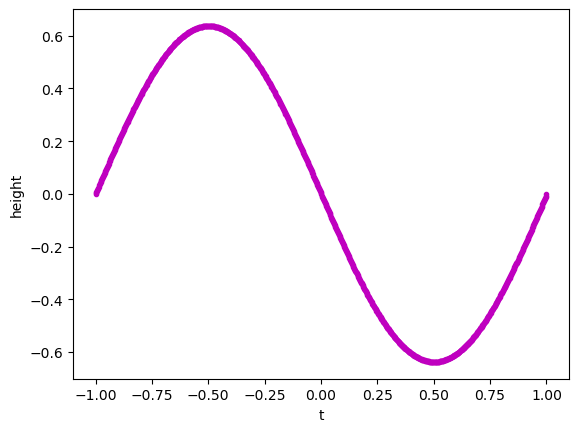

2.0990154059319366e-16


In [44]:

tpts = np.arange(t1,t2+h,h)
ypts = np.zeros(len(tpts))
vpts = np.zeros(len(tpts))

#Initial values
r = np.array([0,2], float)
#Apply 4th order runge-kutta to calculate height. 
#tpts is an array of time values spaced by h
for i in range(len(tpts)):
    ypts[i] = r[0]
    vpts[i] = r[1]
    k1 = h*f(r,tpts[i], z2)
    k2 = h*f(r+0.5*k1, tpts[i]+0.5*h, z2)
    k3 = h*f(r+0.5*k2, tpts[i]+0.5*h, z2)
    k4 = h*f(r+k3, tpts[i]+h, z2)
    r += (k1 + 2*k2 + 2*k3 + k4)/6

#Set the final
ypts[-1] = r[0]
vpts[-1] = r[1]

plt.plot(tpts,ypts,".m")
plt.xlabel("t")
plt.ylabel("height")
plt.show()

print(ypts[-1])

The current value of z does make sense, as it starts at 0 and ends at 0, just like how the initial conditions said it should. What's interesting is when the initial height is changed, the amplitude of the curve changes, reaching a much higher maximum and lower minimum when the initial velocity guess is increased, and all the maxs and mins are less extreme when the initial velocity guess is decreased. 